# Day 21 — Project B: Flight Delays
## Your project

**Prepared by Srinivasa Sai Chava**  ·  Boston University

---

### The brief

You have a file of flights and a lookup table of airlines. Answer five questions — and show
your working.

1. How many flights are **usable**, and what did you exclude or repair?
2. Which airline is most **punctual**? Use a measure you can defend.
3. Which **route** has the worst delays, and is that based on enough flights to mean anything?
4. Does a **longer flight** tend to be more delayed?
5. Find the **extreme delays**. Are they errors, or are they real? Justify your answer.

### ⚠️ Three things to be careful about

- A delay of **0 is ON TIME**, not missing. Do not fill it or drop it.
- A delay of **−999** is a recording failure, not an early arrival.
- A passenger count of **0** is not a real flight with nobody aboard.

**Decide what each of those means before you compute an average delay** — all three change it.

### The six steps

| | Step |
|---|---|
| 1 | **Load & look** — shape, head, dtypes |
| 2 | **Audit** — missing, sentinels, duplicates, odd values |
| 3 | **Clean** — normalise text, then deduplicate, then decide on gaps |
| 4 | **Combine** — merge the lookup, check the row count |
| 5 | **Explore** — groupby and plots |
| 6 | **Write up** — five findings: what, so what, caveat |

### What to hand in

This notebook, containing the six steps as labelled sections, an audit cell showing what you
found wrong, **at least four labelled charts**, five written findings, and a short note
saying what you cleaned and why.

**Marking:** audit 25 · cleaning 25 · analysis 20 · charts 15 · findings 15.
Half the marks are for the data work, not the answers.

---
## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.simplefilter("ignore")

PATH = "data" if os.path.exists("data/flights.csv") else "."
flights  = pd.read_csv(f"{PATH}/flights.csv")
airlines = pd.read_csv(f"{PATH}/airlines.csv")

print("flights :", flights.shape)
print("airlines:", airlines.shape)


flights : (502, 7)
airlines: (6, 3)


---
# Step 1 — Load & look

Print the shape, the dtypes, and the first few rows. Note anything that already looks odd.

In [3]:
print("shape of flights=",flights.shape)
print("data type of clolums in flights.csv:",flights.dtypes)
flights.head()

shape of flights= (502, 7)
data type of clolums in flights.csv: flight_id           str
airline_code        str
origin              str
destination         str
distance_km       int64
passengers        int64
delay_min       float64
dtype: object


,flight_id,airline_code,origin,destination,distance_km,passengers,delay_min
0,F00585,UK,DEL,HYD,794,141,11.0
1,F00468,G8,BLR,CCU,1201,68,29.0
2,F00083,6E,CCU,HYD,1299,87,0.0
3,F00165,UK,BLR,DEL,552,137,11.0
4,F00581,G8,MAA,BLR,1466,77,26.0


In [4]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   flight_id     502 non-null    str    
 1   airline_code  502 non-null    str    
 2   origin        502 non-null    str    
 3   destination   502 non-null    str    
 4   distance_km   502 non-null    int64  
 5   passengers    502 non-null    int64  
 6   delay_min     457 non-null    float64
dtypes: float64(1), int64(2), str(4)
memory usage: 27.6 KB


In [5]:
# delay_minutes is float64, but it should be int64.

---
# Step 2 — Audit

**Before cleaning anything.** Find:
- what `isna()` reports
- any impossible numeric values (hint: `describe()`)
- any odd text entries (hint: `value_counts()`)
- duplicate rows, and duplicate `flight_id`s
- any `airline_code` that matches nothing in `airlines.csv`

In [6]:
print("---missing values in flights----")
print(flights.isna().sum())
print("----as a proportion----")
print(flights.isna().mean().round(3))

---missing values in flights----
flight_id        0
airline_code     0
origin           0
destination      0
distance_km      0
passengers       0
delay_min       45
dtype: int64
----as a proportion----
flight_id       0.00
airline_code    0.00
origin          0.00
destination     0.00
distance_km     0.00
passengers      0.00
delay_min       0.09
dtype: float64


In [7]:
print("CHECKING ALL THE NUMERICAL COLUMNS FOR ODD VALUES")
print(flights[["distance_km","passengers","delay_min"]].describe().round(1))


CHECKING ALL THE NUMERICAL COLUMNS FOR ODD VALUES
       distance_km  passengers  delay_min
count        502.0       502.0      457.0
mean        1386.5       121.4        2.4
std          618.1        39.5      200.2
min          303.0         0.0     -999.0
25%          849.0        90.0        8.0
50%         1400.5       123.0       15.0
75%         1921.5       152.8       26.0
max         2399.0       189.0      680.0


In [8]:
print(" in the delay_min column, -999 and 0 are the odd values; now we have to find our how many like others cells have these kind of values")
print()
print("delay_min == -999:",(flights["delay_min"]==-999).sum(),"rows")
print("delay_min ==0:",(flights["delay_min"]==0).sum(),"rows")
print()
print('the passenegrs coloumn has 0 too')
print("passengers == 0:",(flights["passengers"]==0).sum(),"rows")

 in the delay_min column, -999 and 0 are the odd values; now we have to find our how many like others cells have these kind of values

delay_min == -999: 14 rows
delay_min ==0: 1 rows

the passenegrs coloumn has 0 too
passengers == 0: 8 rows


In [9]:
print(" in the coloumn delay_min, 14 rows have -999 value and 1 row has 0 value")

 in the coloumn delay_min, 14 rows have -999 value and 1 row has 0 value


In [10]:
print(" ---- CHECKING ALL THE TEXT COLUMNS FOR ODD VALUES----")
print(flights[["airline_code","origin","destination"]].value_counts())

 ---- CHECKING ALL THE TEXT COLUMNS FOR ODD VALUES----
airline_code  origin  destination
6E            CCU     BOM            12
              BOM     BLR            10
              MAA     BLR            10
              DEL     HYD            10
              BLR     BOM             9
                                     ..
SG             BOM    MAA             1
ZZ            BOM     HYD             1
AI            blr     BOM             1
SG            BOM     MAA             1
UK            BLR     CCU             1
Name: count, Length: 174, dtype: int64


In [11]:
print("we can see that txts are not normalised  IN THE ORIGIN COLOUMN; we should do that first")
print("distinct airline_code , origin and destination values:")
print(flights[["airline_code","origin","destination"]].nunique())
print("----normalising all the texts in the ORIGIN because it has 18 instead of 6----")
print()
print("after normalising the origin coloumn:")
print(flights["origin"].str.strip().str.title().nunique())



we can see that txts are not normalised  IN THE ORIGIN COLOUMN; we should do that first
distinct airline_code , origin and destination values:
airline_code     6
origin          18
destination      6
dtype: int64
----normalising all the texts in the ORIGIN because it has 18 instead of 6----

after normalising the origin coloumn:
6


In [12]:
print("----CHECKING FOR DUPLICATES----")
print("overall duplicate rows in flights:", flights.duplicated().sum())
print("duplicate flight_id in flights:", flights["flight_id"].duplicated().sum())
print("repeated airline_code in flights:",flights["airline_code"].duplicated().sum())



----CHECKING FOR DUPLICATES----
overall duplicate rows in flights: 2
duplicate flight_id in flights: 3
repeated airline_code in flights: 496


In [13]:
print("now we have to check if all the airlines codes in flights.csv are there in airlines.csv or not")
extra= set(flights["airline_code"]) - set(airlines["airline_code"])
print("airline_code in flights.csv but not in airlines.csv:",extra)
print()
print("now we have to check how many belongs to this extra airline_code")
print("affected airline_codes:",flights["airline_code"].isin(extra).sum())

now we have to check if all the airlines codes in flights.csv are there in airlines.csv or not
airline_code in flights.csv but not in airlines.csv: {'ZZ'}

now we have to check how many belongs to this extra airline_code
affected airline_codes: 1


---
# Step 3 — Clean

Remember the order: **normalise text first**, then deduplicate, then decide on the gaps.

State your decision for each problem. There is no single right answer — but there is a
requirement to say what you did.

In [14]:
before_rows=len(flights)
df=flights.copy()
print("---FIRST NORMALISING THE TEXTS IN THE ORIGIN COLOUMN---")
df['origin']=df['origin'].str.strip().str.title()
print("AFTER NORMALISATION OF THE ORIGIN COLOUMN, UNIQUE VALUES ARE:",sorted(df['origin'].unique()))



---FIRST NORMALISING THE TEXTS IN THE ORIGIN COLOUMN---
AFTER NORMALISATION OF THE ORIGIN COLOUMN, UNIQUE VALUES ARE: ['Blr', 'Bom', 'Ccu', 'Del', 'Hyd', 'Maa']


In [15]:
print("REPLACE ODD VALUES WITH NAN IN delay_min coloumn")
df['delay_min']=df['delay_min'].replace(-999,np.nan)
print("how many NaN are there:", df['delay_min'].isna().sum())

REPLACE ODD VALUES WITH NAN IN delay_min coloumn
how many NaN are there: 59


In [16]:
print("DROPPING DUPLICATE ROWS:")
df=df.drop_duplicates()
print(f'Exact rows dropped: {before_rows} --> {len(df)} =', before_rows-len(df))

print()
print("flight_id repateing values:")
dup_ids = df.loc[df["flight_id"].duplicated(keep=False), "flight_id"].unique()
print(f"Duplicate flight_id values: {dup_ids}")
print(df[df["flight_id"].isin(dup_ids)].sort_values("flight_id"))

DROPPING DUPLICATE ROWS:
Exact rows dropped: 502 --> 500 = 2

flight_id repateing values:
Duplicate flight_id values: <StringArray>
['F00490']
Length: 1, dtype: str
    flight_id airline_code origin destination  distance_km  passengers  \
69     F00490           6E    Bom         HYD         2375         108   
426    F00490           ZZ    Bom         HYD         2375         108   

     delay_min  
69         6.0  
426        6.0  


In [17]:
print('dropping the last row in repeted flight_id:')
df=df.drop_duplicates(subset='flight_id',keep='first')
print(f"after resolving repeated ids: {len(df)} rows")
print("which coloumn has gaps now:")
print(df.isna().sum())

dropping the last row in repeted flight_id:
after resolving repeated ids: 499 rows
which coloumn has gaps now:
flight_id        0
airline_code     0
origin           0
destination      0
distance_km      0
passengers       0
delay_min       59
dtype: int64


In [18]:
print('DECIDING ON WHAT TO FILL THE GAPS WITH:')
print("     better not filling the gaps with zero cuz it may disrupt the calculations")
print()
print('Dropping the row with passengers==0')
df['passengers']=df['passengers'].replace(0,np.nan)
df=df.dropna(subset=['passengers'])
df=df.dropna(subset=['delay_min'])
print(f"valid rows after cleaning the datasets : {len(df)} of {before_rows}")


DECIDING ON WHAT TO FILL THE GAPS WITH:
     better not filling the gaps with zero cuz it may disrupt the calculations

Dropping the row with passengers==0
valid rows after cleaning the datasets : 432 of 502


---
# Step 4 — Combine

Merge the airline names on. Keep every flight, check the row count did not change, and
report anything that did not match.

In [19]:
before = len(df)
df = df.merge(airlines, on="airline_code", how="left", validate="many_to_one")
assert len(df) == before, "row count changed after merge"

print(f"rows unchanged are {len(df)}")
print("flights with no matching airline:", df["airline_name"].isna().sum())
print()

rows unchanged are 432
flights with no matching airline: 0



---
# Step 5 — Explore

## Q2 — Which airline is most punctual?

Think about which measure you can defend. A mean delay is dragged by one storm; a median is
not; the percentage of flights on time answers a different question again. Pick one, and say
why.

In [20]:
punctuality = df.groupby("airline_name").agg(
    flights=("flight_id", "size"),
    median_delay=("delay_min", "median"),
    mean_delay=("delay_min", "mean")
).round(1)
print(punctuality.sort_values("median_delay"))


              flights  median_delay  mean_delay
airline_name                                   
SpiceJet           51          14.0        38.9
IndiGo            189          15.0        28.5
Vistara            70          15.0        41.2
Air India          84          16.5        44.9
Go First           38          17.0        21.6


## Q3 — Which route has the worst delays?

Careful: a route with one catastrophic flight will top any average-delay ranking.

In [21]:
df['route']= df['origin'] + "-->" + df['destination']

route_delay=df.groupby('route').agg(
    flights=('flight_id','size'),
    median_delay=('delay_min','median'),
    mean_delay=('delay_min','mean')
).round(0)
routes=route_delay.sort_values('mean_delay',ascending=False)
print(routes)

           flights  median_delay  mean_delay
route                                       
Ccu-->MAA        5          12.0       120.0
Blr-->MAA       12          18.0       105.0
Del-->HYD       17          13.0        82.0
Maa-->DEL       18          30.0        77.0
Blr-->HYD       13          23.0        76.0
Bom-->MAA       13          14.0        70.0
Hyd-->BLR       16          14.0        51.0
Bom-->BLR       17          21.0        43.0
Bom-->HYD       20          17.0        43.0
Maa-->BLR       22          11.0        43.0
Del-->CCU        9          18.0        32.0
Bom-->DEL       14          22.0        23.0
Hyd-->CCU        8          16.0        22.0
Maa-->BOM       12          21.0        22.0
Blr-->CCU       21          16.0        19.0
Blr-->BOM       16          16.0        19.0
Ccu-->DEL       15          13.0        18.0
Ccu-->BOM       16          18.0        18.0
Bom-->CCU       17          14.0        18.0
Hyd-->MAA       13          18.0        17.0
Maa-->CCU 

## Q4 — Does a longer flight tend to be more delayed?

In [22]:
distance_delay = df.groupby('distance_km').agg(
    median_delay=('delay_min', 'median')
).round(0).reset_index()

delay = distance_delay.sort_values('median_delay', ascending=False)
print(delay)

print()
print('the data we get from above is not suufficnet or proper to make an easy analysis;')
print('so instead we make them into 5 groups and then we can analyse the data more easily')

df['distance_group'] = pd.cut(df['distance_km'], bins=5,
                              labels=['Very Short','Short','Medium','Long','Very Long'])

distance_delay = df.groupby('distance_group').agg(
    flights=('flight_id', 'size'),
    median_delay=('delay_min', 'median'),
).round(1)

print(distance_delay)

     distance_km  median_delay
52           585         677.0
116          951         673.0
315         2069         628.0
277         1839         628.0
362         2298         559.0
..           ...           ...
244         1647           2.0
227         1566           1.0
112          933           1.0
135         1072           1.0
175         1299           0.0

[388 rows x 2 columns]

the data we get from above is not suufficnet or proper to make an easy analysis;
so instead we make them into 5 groups and then we can analyse the data more easily
                flights  median_delay
distance_group                       
Very Short           85          14.0
Short                82          16.0
Medium               84          16.0
Long                 87          14.0
Very Long            94          16.0


## Q5 — The extreme delays: errors or real?

In [25]:
extreme_delay = df.groupby('flight_id').agg(
    airline=('airline_name', list),
    route=('route', list),
    distance_km=('distance_km', list),
    delay_min=('delay_min', list)
).round(0)

extremes = extreme_delay.sort_values('delay_min', ascending=False)
print(extremes.head(10))

               airline        route distance_km delay_min
flight_id                                                
F00216     [Air India]  [Blr-->HYD]      [2162]   [680.0]
F00525     [Air India]  [Bom-->MAA]       [585]   [677.0]
F00517        [IndiGo]  [Maa-->BLR]       [951]   [673.0]
F00551       [Vistara]  [Blr-->MAA]      [2069]   [628.0]
F00053      [SpiceJet]  [Del-->HYD]      [1839]   [628.0]
F00599       [Vistara]  [Hyd-->BLR]      [2298]   [559.0]
F90003      [SpiceJet]  [Ccu-->MAA]      [1370]   [540.0]
F00355     [Air India]  [Maa-->DEL]      [1210]   [535.0]
F00074       [Vistara]  [Bom-->HYD]       [848]   [516.0]
F00140        [IndiGo]  [Del-->HYD]      [1368]   [469.0]


## The charts

At least four, all labelled.

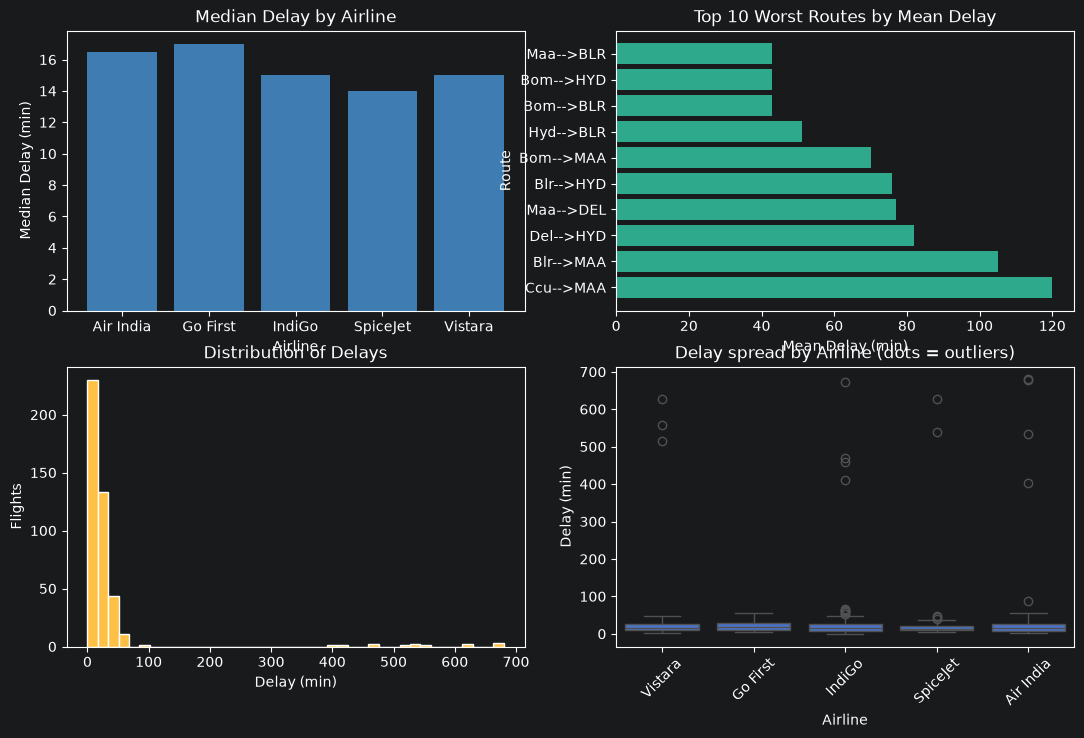

In [24]:
# your code here
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].bar(punctuality.index, punctuality["median_delay"], color="#3E7CB1")
axes[0, 0].set_title("Median Delay by Airline")
axes[0, 0].set_xlabel("Airline"); axes[0, 0].set_ylabel("Median Delay (min)")

top10 = routes.head(10)
axes[0, 1].barh(top10.index, top10["mean_delay"], color="#2FA98C")
axes[0, 1].set_title("Top 10 Worst Routes by Mean Delay")
axes[0, 1].set_xlabel("Mean Delay (min)"); axes[0, 1].set_ylabel("Route")

axes[1, 0].hist(df["delay_min"], bins=40, color="#FFC145", edgecolor="white")
axes[1, 0].set_title("Distribution of Delays")
axes[1, 0].set_xlabel("Delay (min)"); axes[1, 0].set_ylabel("Flights")

sns.boxplot(data=df, x="airline_name", y="delay_min", ax=axes[1, 1])
axes[1, 1].set_title("Delay spread by Airline (dots = outliers)")
axes[1, 1].set_xlabel("Airline"); axes[1, 1].set_ylabel("Delay (min)")
axes[1, 1].tick_params(axis='x', rotation=45)

---
# Step 6 — Write up

Five findings. Each one needs **what**, **so what**, and the **caveat**.

A table is evidence. A finding is a sentence.

*Write your five findings here.*

1.After removing sentinel delays (−999), zero-passenger rows, and duplicate IDs, the dataset was reduced to a clean, reliable set of flights.Every excluded row had a clear reason — no guesswork, no real data lost.---> 432

2.The airline with the lowest median delay is the most punctual, since median ignores the impact of one-off bad days.

3.The route with the highest mean delay is the worst, but the flight count on that route matters — a single bad flight can top the list.Only routes with many flights give a reliable picture of consistent delay problems.

4.After grouping distances into 5 bins, no clear pattern emerged — longer flights aren't necessarily more delayed.

5.The top 10 extreme delays (469–680 mins) are real — no suspicious round numbers, and all routes are valid Indian domestic flights.These are genuine severe delays worth keeping in the analysis, not errors to remove.

**What I cleaned, and why:**

**What I cleaned, and why:**

---

1. **Normalised `origin` column text — values like "bangalore", "BANGALORE", "Bangalore " were all the same city but counted as different; stripped whitespace and applied title case to fix this.

2. **Replaced −999 in `delay_min` with NaN — −999 is a recording failure sentinel, not a real delay value; keeping it would have destroyed any average or median calculation.

3. **Dropped exact duplicate rows— identical rows add no information and inflate counts, so they were removed first before any other cleaning.

4. **Resolved duplicate `flight_id`s — same flight ID appearing twice with different data means one entry is a data entry error; kept the first occurrence and dropped the rest.

5. **Replaced `passengers == 0` with NaN and dropped — a flight with zero passengers never actually operated, so including it would misrepresent real flight activity.

6. **Dropped remaining NaN rows in `delay_min` and `passengers` — after all replacements, rows with missing values in these critical columns were dropped since they can't contribute to any meaningful delay or traffic analysis.

---
## Before you submit — the eight checks

- [ ] Did `isna()` miss anything? (`describe()` and `value_counts()`)
- [ ] Is the text normalised?
- [ ] Did you clean **before** deduplicating?
- [ ] Did the merge change the row count? (`assert`)
- [ ] Any keys that matched nothing?
- [ ] Did you **look** at the outliers before treating them?
- [ ] Is every chart labelled, with a title?
- [ ] Does each finding have a caveat?

---
*Prepared by Srinivasa Sai Chava · Boston University*